In [1]:
import pandas as pd

df=pd.read_csv("QVI_data.csv")
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [2]:
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [4]:
df.columns.tolist()

['LYLTY_CARD_NBR',
 'DATE',
 'STORE_NBR',
 'TXN_ID',
 'PROD_NBR',
 'PROD_NAME',
 'PROD_QTY',
 'TOT_SALES',
 'PACK_SIZE',
 'BRAND',
 'LIFESTAGE',
 'PREMIUM_CUSTOMER']

In [5]:
df["DATE"]=pd.to_datetime(df["DATE"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [7]:
df["MONTH"]=df["DATE"].dt.to_period("M")

In [8]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11


In [9]:
#metrics

monthly=df.groupby(["STORE_NBR","MONTH"]).agg(

    total_sales=("TOT_SALES","sum"),
    total_customers=("LYLTY_CARD_NBR","nunique"),
    total_txn=("TXN_ID","count")

).reset_index()

In [10]:
monthly

,STORE_NBR,MONTH,total_sales,total_customers,total_txn
0,1,2018-07,206.9,49,52
1,1,2018-08,176.1,42,43
2,1,2018-09,278.8,59,62
3,1,2018-10,188.1,44,45
4,1,2018-11,192.6,46,47
...,...,...,...,...,...
3164,272,2019-02,395.5,45,48
3165,272,2019-03,442.3,50,53
3166,272,2019-04,445.1,54,56
3167,272,2019-05,314.6,34,40


In [11]:
monthly["avg_txns_per_customer"] = (
    monthly["total_txn"] / monthly["total_customers"]
)

In [12]:
monthly

,STORE_NBR,MONTH,total_sales,total_customers,total_txn,avg_txns_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,1.066667
3165,272,2019-03,442.3,50,53,1.060000
3166,272,2019-04,445.1,54,56,1.037037
3167,272,2019-05,314.6,34,40,1.176471


In [13]:
trial_stores=[77,86,88]

trial_data=monthly[monthly["STORE_NBR"].isin(trial_stores)]

In [14]:
trial_data

,STORE_NBR,MONTH,total_sales,total_customers,total_txn,avg_txns_per_customer
880,77,2018-07,296.80,51,55,1.078431
881,77,2018-08,255.50,47,48,1.021277
882,77,2018-09,225.20,42,44,1.047619
883,77,2018-10,204.50,37,38,1.027027
884,77,2018-11,245.30,41,44,1.073171
885,77,2018-12,267.30,46,49,1.065217
886,77,2019-01,204.40,35,39,1.114286
887,77,2019-02,235.00,45,45,1.000000
888,77,2019-03,278.50,50,55,1.100000
889,77,2019-04,263.50,47,48,1.021277


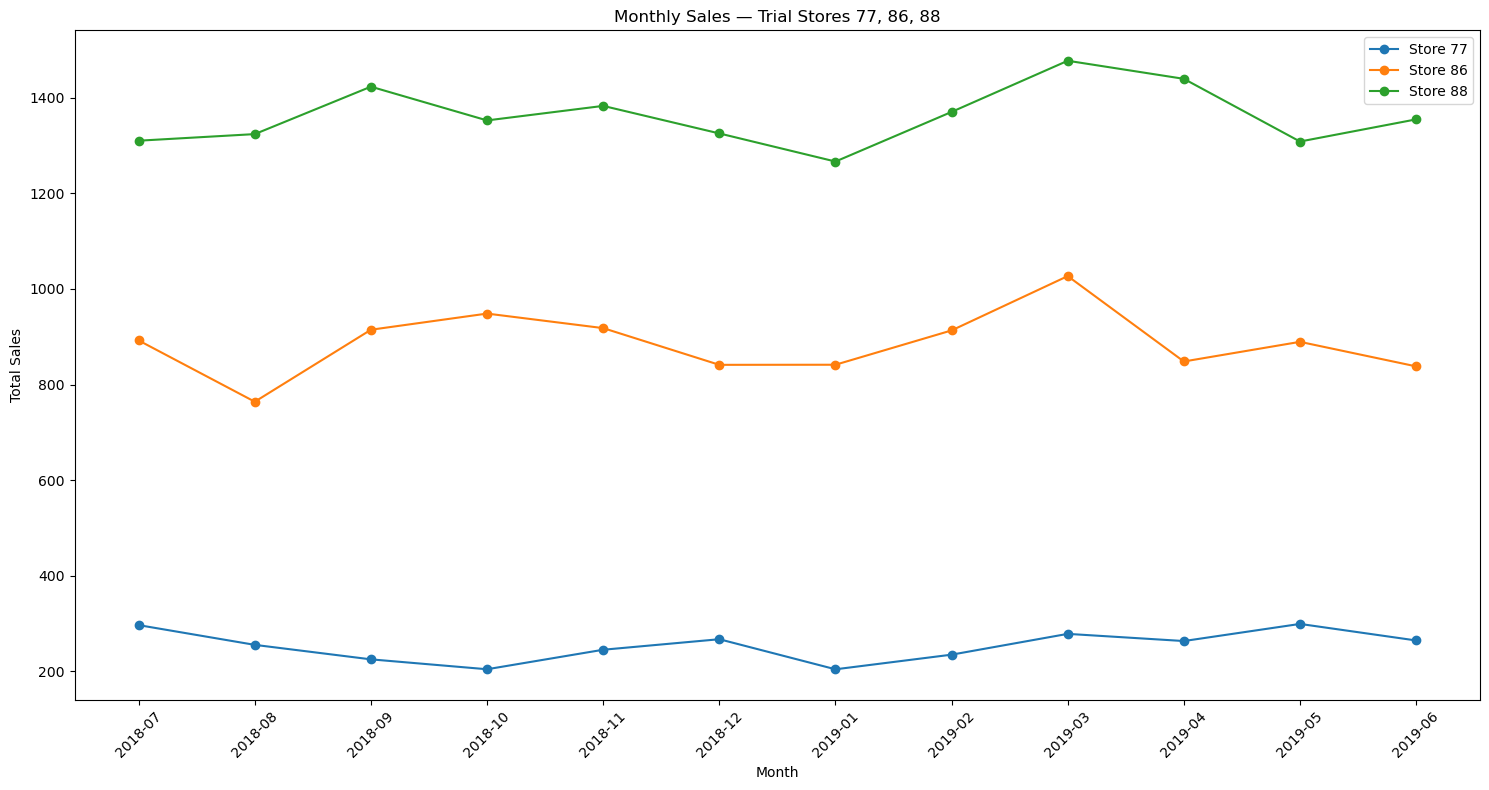

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for store in trial_stores:
    store_data=trial_data[trial_data["STORE_NBR"]==store]
    plt.plot(
        store_data["MONTH"].astype(str),
        store_data["total_sales"],
        marker="o",
        label=f"Store {store}"
    )

plt.title("Monthly Sales — Trial Stores 77, 86, 88")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


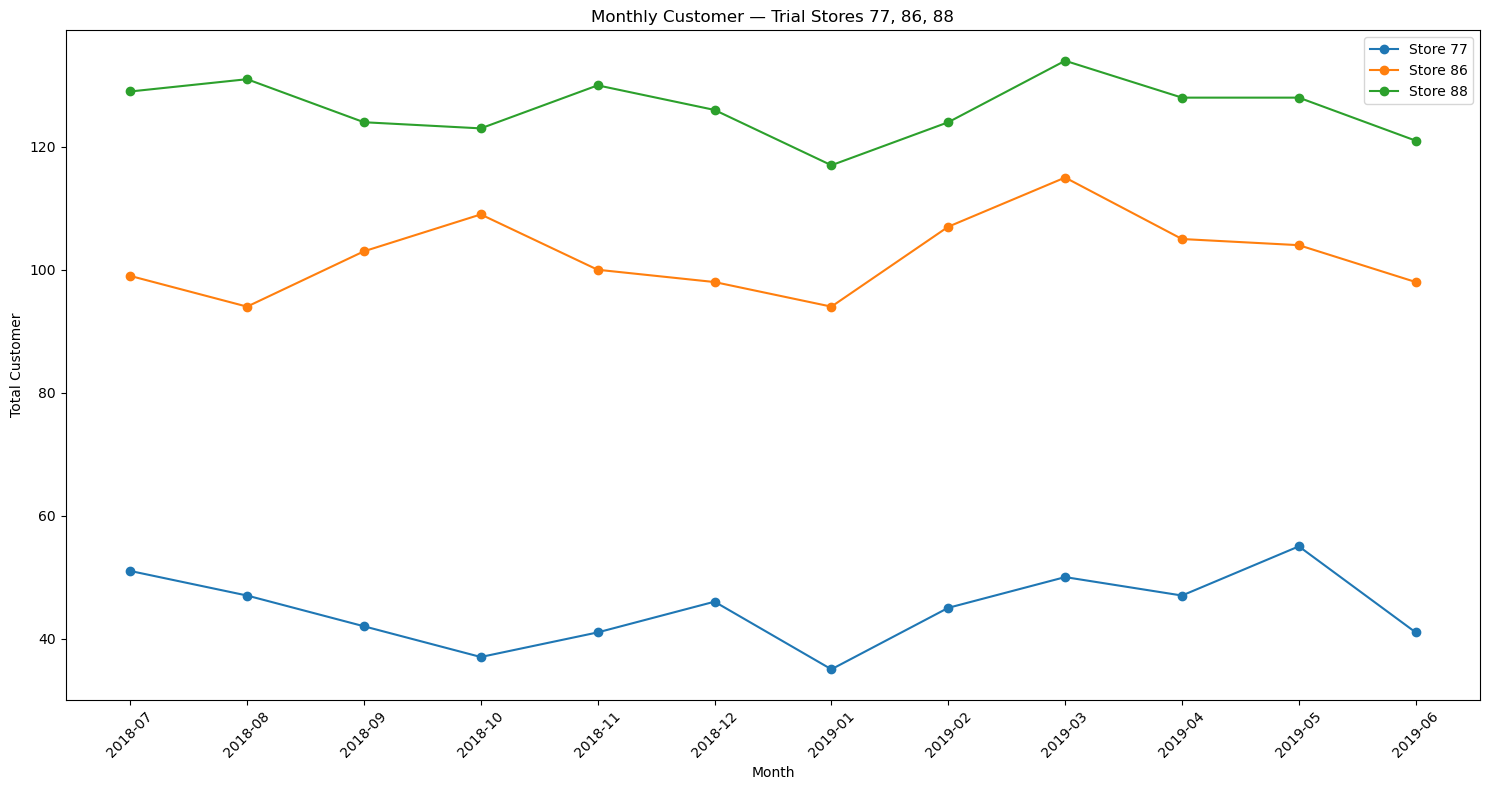

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for store in trial_stores:
    store_data=trial_data[trial_data["STORE_NBR"]==store]
    plt.plot(
        store_data["MONTH"].astype(str),
        store_data["total_customers"],
        marker="o",
        label=f"Store {store}"
    )

plt.title("Monthly Customer — Trial Stores 77, 86, 88")
plt.xlabel("Month")
plt.ylabel("Total Customer")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
pre_trial = monthly[monthly["MONTH"] <"2019-02"]

print("Pre-trial months:")
print((pre_trial["MONTH"].unique()))
print("Shape:", pre_trial.shape)

Pre-trial months:
<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]
Shape: (1848, 6)


In [18]:
pre_trial

,STORE_NBR,MONTH,total_sales,total_customers,total_txn,avg_txns_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3159,272,2018-09,304.7,32,36,1.125000
3160,272,2018-10,430.6,44,51,1.159091
3161,272,2018-11,376.2,41,45,1.097561
3162,272,2018-12,403.9,47,47,1.000000


In [19]:
def get_similarity(df1,df2,metric):


    merged=df1[["MONTH",metric]].merge(df2[["MONTH",metric]],on="MONTH",suffixes=("_1","_2"))

    if len(merged)<3:
        return 0
    
    score = merged[f"{metric}_1"].corr(merged[f"{metric}_2"])

    if pd.isna(score):
        score = 0
    
    return round(score, 4)

In [20]:
def find_control_store(trial_nbr):
    trial = pre_trial[pre_trial["STORE_NBR"] == trial_nbr]
    other_nbrs = pre_trial[~pre_trial["STORE_NBR"].isin([77,86,88])]["STORE_NBR"].unique()
    
    results = []
    for nbr in other_nbrs:
        other = pre_trial[pre_trial["STORE_NBR"] == nbr]
        s1 = get_similarity(trial, other, "total_sales")
        s2 = get_similarity(trial, other, "total_customers")
        s3 = get_similarity(trial, other, "avg_txns_per_customer")
        results.append({"store": nbr, "score": round((s1+s2+s3)/3, 4)})
    
    results_df = pd.DataFrame(results).sort_values("score", ascending=False)
    best = int(results_df.iloc[0]["store"])
    print(f"Trial {trial_nbr} → Control {best} (score: {results_df.iloc[0]['score']})")
    return best

In [21]:
import warnings
warnings.filterwarnings("ignore")

control_77 = find_control_store(77)
control_86 = find_control_store(86)
control_88 = find_control_store(88)


Trial 77 → Control 119 (score: 0.8544)
Trial 86 → Control 138 (score: 0.7121)
Trial 88 → Control 178 (score: 0.755)


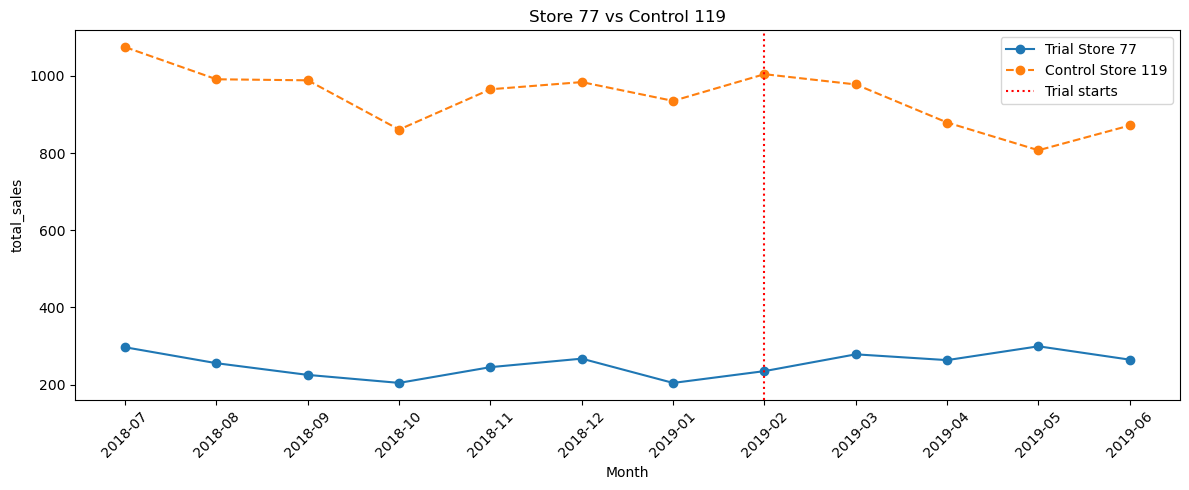

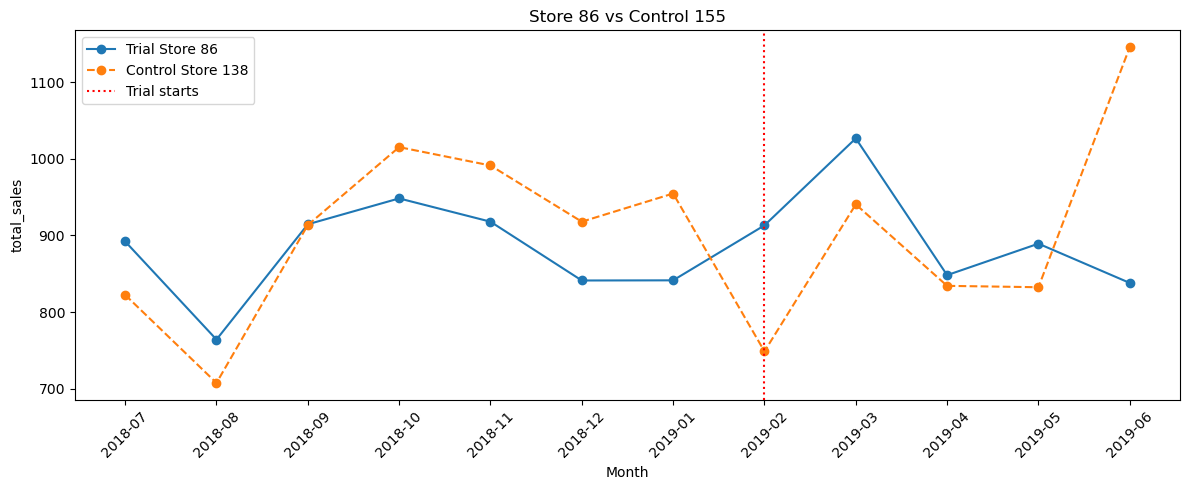

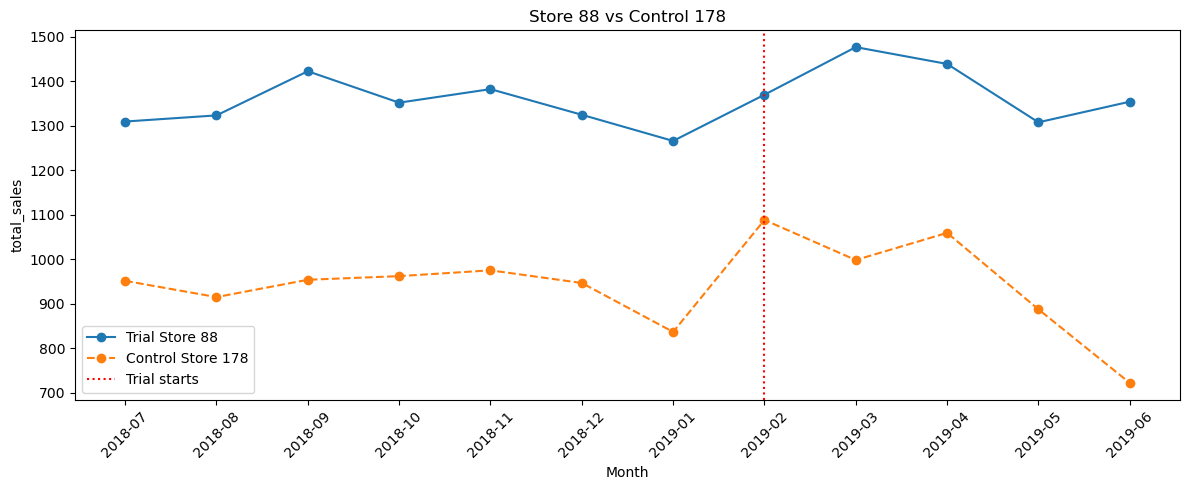

In [24]:
def plot_trial_vs_control(trial_nbr, control_nbr, metric, title):
    trial   = monthly[monthly["STORE_NBR"] == trial_nbr]
    control = monthly[monthly["STORE_NBR"] == control_nbr]

    plt.figure(figsize=(12, 5))
    plt.plot(trial["MONTH"].astype(str),   trial[metric],   marker="o", label=f"Trial Store {trial_nbr}")
    plt.plot(control["MONTH"].astype(str), control[metric], marker="o", label=f"Control Store {control_nbr}", linestyle="--")
    plt.axvline(x="2019-02", color="red", linestyle=":", label="Trial starts")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# plot all 3 pairs
plot_trial_vs_control(77,  control_77, "total_sales", "Store 77 vs Control 119")
plot_trial_vs_control(86,  control_86, "total_sales", "Store 86 vs Control 155")
plot_trial_vs_control(88,  control_88, "total_sales", "Store 88 vs Control 178")